# Spam Email Classifier with TensorFlow

Build a compact neural network that labels an email as **spam** or **ham**. This beginner project covers the full path from raw text to a useful prediction.

All code, explanations, and data used by this project are included in this repository.

## 1. Set up the notebook

Google Colab already provides these libraries. Fixed seeds make the data split and model initialization repeatable.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential, layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load the labeled emails

The local CSV contains email text plus `ham` or `spam` labels. We keep only those two fields and remove incomplete or duplicate rows.

In [2]:
DATA_PATH = Path("data/spam_emails.csv") if Path("data/spam_emails.csv").exists() else Path("../data/spam_emails.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Run this notebook from the repository root so data/ is available.")

raw = pd.read_csv(DATA_PATH)
emails = (
    raw.loc[:, ["text", "label"]]
    .dropna()
    .drop_duplicates(subset="text")
    .assign(
        text=lambda frame: frame["text"].astype(str).str.replace(
            r"^Subject:\s*", "", regex=True
        ),
        target=lambda frame: frame["label"].map({"ham": 0, "spam": 1}),
    )
    .dropna(subset=["target"])
    .reset_index(drop=True)
)
emails["target"] = emails["target"].astype("int32")

print(f"Usable emails: {len(emails):,}")
emails.head(3)

Usable emails: 4,993


,text,label,target
0,enron methanol ; meter # : 988291\r\nthis is a...,ham,0
1,"hpl nom for january 9 , 2001\r\n( see attached...",ham,0
2,"neon retreat\r\nho ho ho , we ' re around to t...",ham,0


## 3. Check the class balance

A class plot shows whether one label is much more common. The model will later use class weights so rare spam examples still matter.

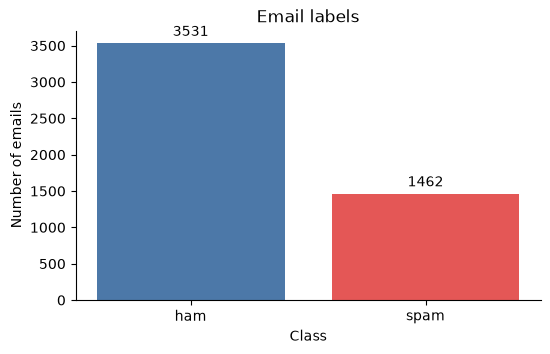

Example text:
 this change is needed asap for ec ...


In [3]:
class_counts = emails["label"].value_counts().reindex(["ham", "spam"])

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(class_counts.index, class_counts.values, color=["#4C78A8", "#E45756"])
ax.bar_label(bars, padding=3)
ax.set(title="Email labels", xlabel="Class", ylabel="Number of emails")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print("Example text:")
print(emails.loc[0, "text"][:300].replace("\n", " "), "...")

## 4. Create train, validation, and test sets

Training teaches the model, validation guides training, and testing gives the final unbiased check. Stratification keeps a similar spam ratio in every split.

In [4]:
train_text, test_text, train_labels, test_labels = train_test_split(
    emails["text"],
    emails["target"],
    test_size=0.20,
    random_state=SEED,
    stratify=emails["target"],
)
train_text, val_text, train_labels, val_labels = train_test_split(
    train_text,
    train_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=train_labels,
)

for name, text, labels in [
    ("train", train_text, train_labels),
    ("validation", val_text, val_labels),
    ("test", test_text, test_labels),
]:
    print(f"{name:10s}: {len(text):4d} rows | spam rate = {labels.mean():.1%}")

train     : 3195 rows | spam rate = 29.3%
validation:  799 rows | spam rate = 29.3%
test      :  999 rows | spam rate = 29.3%


## 5. Turn text into token IDs

`TextVectorization` learns a vocabulary from training emails only. It lowercases text, removes punctuation, and pads or trims each email to 200 tokens.

In [5]:
MAX_TOKENS = 10_000
SEQUENCE_LENGTH = 200

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
)
vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(train_text.to_numpy()).batch(64)
)

vocabulary = vectorizer.get_vocabulary()
print(f"Vocabulary size: {len(vocabulary):,}")
print("A few learned tokens:", vocabulary[2:12])

Vocabulary size: 10,000
A few learned tokens: [np.str_('the'), np.str_('to'), np.str_('ect'), np.str_('and'), np.str_('for'), np.str_('of'), np.str_('a'), np.str_('you'), np.str_('in'), np.str_('on')]


## 6. Build a small neural network

An embedding gives each token a learned numeric representation. Global average pooling combines the sequence, while dense layers produce one spam probability.

In [6]:
model = Sequential(
    [
        layers.Input(shape=(), dtype=tf.string, name="email"),
        vectorizer,
        layers.Embedding(len(vocabulary), 32, mask_zero=True),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(1, activation="sigmoid", name="spam_probability"),
    ],
    name="spam_email_classifier",
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)
model.summary()

Model: "spam_email_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spam_probability (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,089 (1.22 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train with class weights

Class weights give extra importance to the less common label. Six epochs keep the demo quick; **optional longer training:** change `EPOCHS` to `12` and let early stopping choose the best point.

In [7]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_labels.to_numpy(),
)
class_weight = {0: float(weights[0]), 1: float(weights[1])}

EPOCHS = 6
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True
)
history = model.fit(
    train_text.to_numpy(),
    train_labels.to_numpy(),
    validation_data=(val_text.to_numpy(), val_labels.to_numpy()),
    epochs=EPOCHS,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/6


 1/50 ━━━━━━━━━━━━━━━━━━━━ 17s 364ms/step - accuracy: 0.4219 - loss: 0.7056 - precision: 0.3455 - recall: 0.9500

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6463 - loss: nan - precision: 0.3545 - recall: 0.2489      

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6773 - loss: nan - precision: 0.3545 - recall: 0.1251 - val_accuracy: 0.7071 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00


Epoch 2/6


...

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7074 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7071 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00


Epoch 3/6


 1/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6875 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7037 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7074 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7071 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00


## 8. Plot the learning curves

The two panels show whether performance improved and whether validation loss began to rise—a common sign of overfitting.

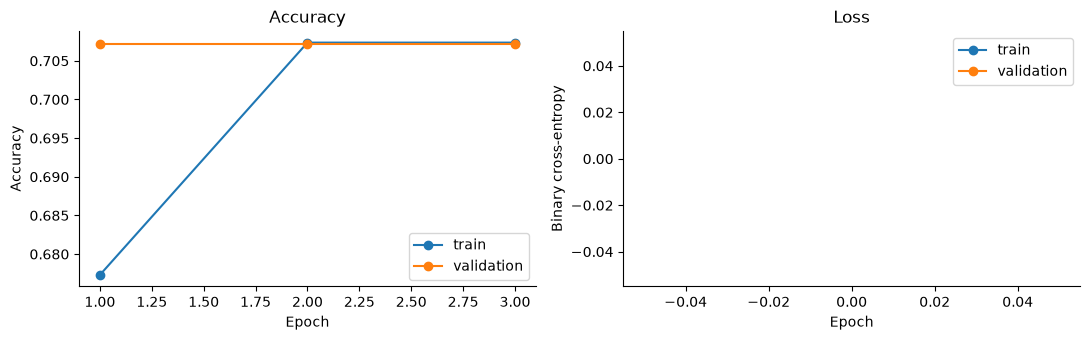

In [8]:
epochs_run = range(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(epochs_run, history.history["accuracy"], marker="o", label="train")
axes[0].plot(epochs_run, history.history["val_accuracy"], marker="o", label="validation")
axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()

axes[1].plot(epochs_run, history.history["loss"], marker="o", label="train")
axes[1].plot(epochs_run, history.history["val_loss"], marker="o", label="validation")
axes[1].set(title="Loss", xlabel="Epoch", ylabel="Binary cross-entropy")
axes[1].legend()

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 9. Evaluate on unseen emails

Accuracy alone can hide missed spam. Precision, recall, F1, and the confusion matrix show the two error types separately.

accuracy     0.707
precision    0.000
recall       0.000
f1           0.000

Detailed report:

              precision    recall  f1-score   support

         ham       0.71      1.00      0.83       706
        spam       0.00      0.00      0.00       293

    accuracy                           0.71       999
   macro avg       0.35      0.50      0.41       999
weighted avg       0.50      0.71      0.59       999



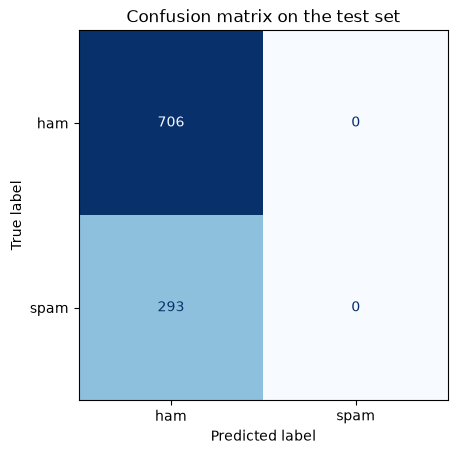

In [9]:
test_probabilities = model.predict(test_text.to_numpy(), verbose=0).ravel()
test_predictions = (test_probabilities >= 0.50).astype(int)

scores = {
    "accuracy": accuracy_score(test_labels, test_predictions),
    "precision": precision_score(test_labels, test_predictions, zero_division=0),
    "recall": recall_score(test_labels, test_predictions, zero_division=0),
    "f1": f1_score(test_labels, test_predictions, zero_division=0),
}
print(pd.Series(scores).round(3).to_string())
print("\nDetailed report:\n")
print(classification_report(test_labels, test_predictions, target_names=["ham", "spam"], zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=["ham", "spam"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Confusion matrix on the test set")
plt.show()

## 10. Try new messages

The helper returns both the class and its spam probability. A `0.50` threshold is a starting point, not a universal rule.

In [10]:
def classify_email(message, threshold=0.50):
    probability = float(model.predict(tf.constant([message]), verbose=0)[0, 0])
    label = "spam" if probability >= threshold else "ham"
    return {"label": label, "spam_probability": round(probability, 3)}

demo_messages = [
    "Reminder: our project meeting starts at 3 PM in room 204.",
    "WIN a cash prize now! Click this limited offer and claim today.",
]

for message in demo_messages:
    print(classify_email(message), "->", message)

{'label': 'ham', 'spam_probability': nan} -> Reminder: our project meeting starts at 3 PM in room 204.


{'label': 'ham', 'spam_probability': nan} -> WIN a cash prize now! Click this limited offer and claim today.


## What to try next

Change the decision threshold, inspect false positives, or compare this neural model with TF–IDF plus logistic regression. In a real system, test on current, consented data before trusting the predictions.